# 1.Package Import

In [2]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict

import pickle

# 2. Global file location (need to specify your own path)

In [3]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [5]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

In [ ]:
# nwb_df, bids_df = data_summary.run_summary(NWB_DIR, BIDS_DIR, max_nwb_files=3, max_bids_files_each=5)

# nwb_df.head(), bids_df.head()

# 3. Load labels and data

In [13]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(face_annots)

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

# print(scenecut_info.head())

In [22]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [4]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [28]:
sub_nums = [41,42]

data = load_data_into_dict.load_multimodal_subjects(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=20000,
    load_fmri=False
)

print(data[41].keys())
# print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]

dict_keys(['spikes', 'firing_rate', 'lfp_macro', 'lfp_micro', 'lfp_bandpower', 'eye_gaze', 'pupil', 'movie_time', 'bold', 'meta'])
(11971, 96) (11971, 2)
n_units: 7 firing_rate: (11971, 7)
band keys: ['theta', 'alpha', 'beta', 'gamma', 'high_gamma']


In [8]:
eye_data = data[41]["eye_gaze"]
print("movie_time shape:", data[41]["movie_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print("eye_gaze sample:", eye_data[0])

movie_time shape: (11971,)
eye_gaze shape: (11971, 2)
eye_gaze sample: [630. 548.]


Text(0.5, 1.0, 'PCA Explained Variance')

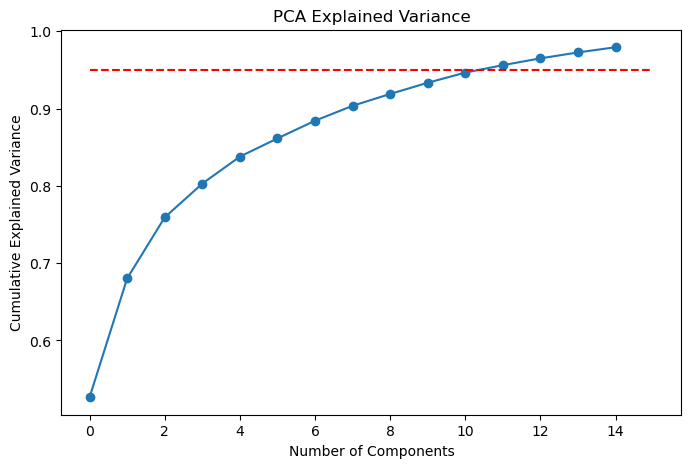

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

X = data[41]["lfp_macro"][:100,:]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.hlines(0.95, 0, len(pca.explained_variance_ratio_), colors='r', linestyles='dashed')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

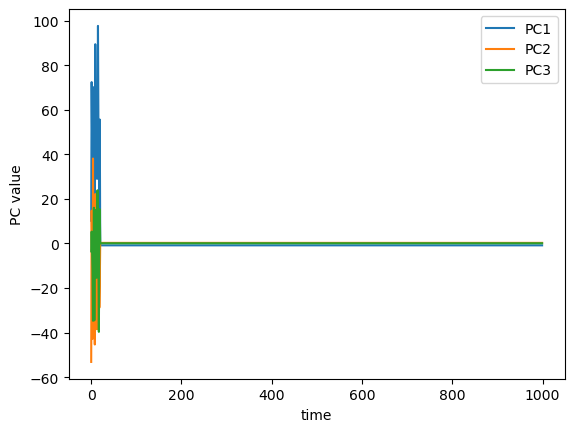

In [35]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:1000, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.show()